,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325200,41.000000,6.984127,1.023810,322.000000,2.555556,37.880000,-122.230000,4.526000
1,8.301400,21.000000,6.238137,0.971880,2401.000000,2.109842,37.860000,-122.220000,3.585000
2,7.257400,52.000000,8.288136,1.073446,496.000000,2.802260,37.850000,-122.240000,3.521000
3,5.643100,52.000000,5.817352,1.073059,558.000000,2.547945,37.850000,-122.250000,3.413000
4,3.846200,52.000000,6.281853,1.081081,565.000000,2.181467,37.850000,-122.250000,3.422000


,Model Name,RMSE Score (Lower is Better),R² Accuracy Score
0,Linear Regression,0.745581,0.575788
1,Decision Tree Regressor,0.703729,0.622076


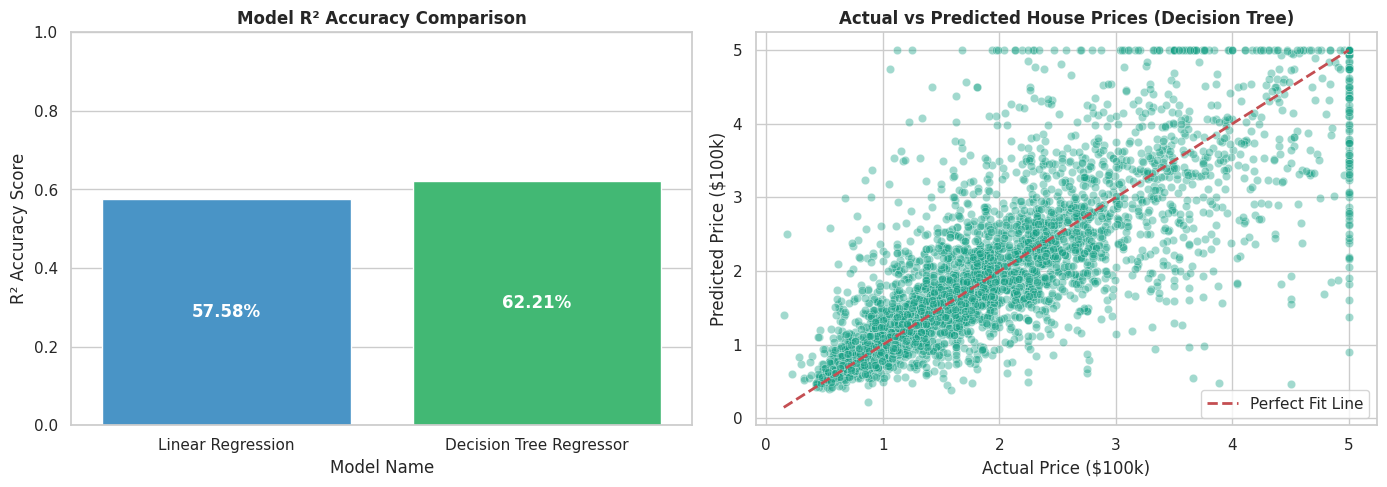

📍 Sample House Features:
{'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}

💵 Actual Price: $47,700.00
🔮 Predicted Price (ML Model): $41,400.00


In [4]:
# ==============================================================================
# SYNENT TECHNOLOGIES - TASK 1: HOUSE PRICE PREDICTION ML MODEL
# Student Name: Unnati Gore | Program: Data Science
# ==============================================================================

import warnings
warnings.filterwarnings('ignore') # Clean screen recording ke liye sabhi warnings hide ki hain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display, HTML

# Visual Styling Setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# 1. DATASET LOADING
data = fetch_california_housing(as_frame=True)
df = data.frame

display(HTML("<h2 style='color: #008080; font-family: sans-serif;'>📊 Step 1: California Housing Dataset Overview</h2>"))
display(df.head().style.background_gradient(cmap='PuBu'))

# 2. FEATURE & TARGET SELECTION
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. MODEL TRAINING & EVALUATION
lr = LinearRegression().fit(X_train, y_train)
dt = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

results_df = pd.DataFrame({
    'Model Name': ['Linear Regression', 'Decision Tree Regressor'],
    'RMSE Score (Lower is Better)': [np.sqrt(mean_squared_error(y_test, lr_pred)), np.sqrt(mean_squared_error(y_test, dt_pred))],
    'R² Accuracy Score': [r2_score(y_test, lr_pred), r2_score(y_test, dt_pred)]
})

display(HTML("<h2 style='color: #008080; font-family: sans-serif;'>🤖 Step 2: Machine Learning Model Comparison</h2>"))
display(results_df.style.highlight_max(subset=['R² Accuracy Score'], color='#b4eeb4')
                      .highlight_min(subset=['RMSE Score (Lower is Better)'], color='#b4eeb4'))

# 4. VISUAL DASHBOARD (Warning Fixed)
display(HTML("<h2 style='color: #008080; font-family: sans-serif;'>📈 Step 3: Visual Performance Dashboard</h2>"))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Model Accuracy Bar Chart
sns.barplot(x='Model Name', y='R² Accuracy Score', hue='Model Name', data=results_df, ax=axes[0], palette=['#3498db', '#2ecc71'], legend=False)
axes[0].set_title("Model R² Accuracy Comparison", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Plot 2: Actual vs Predicted Prices
sns.scatterplot(x=y_test, y=dt_pred, alpha=0.4, color='#16a085', ax=axes[1])
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit Line")
axes[1].set_title("Actual vs Predicted House Prices (Decision Tree)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Actual Price ($100k)")
axes[1].set_ylabel("Predicted Price ($100k)")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. LIVE PREDICTION DEMO
display(HTML("<h2 style='color: #008080; font-family: sans-serif;'>🏠 Step 4: Sample Live Prediction Demo</h2>"))
sample_house = X_test.iloc[0:1]
actual_price = y_test.iloc[0] * 100000
predicted_price = dt.predict(sample_house)[0] * 100000

print(f"📍 Sample House Features:\n{sample_house.to_dict(orient='records')[0]}\n")
print(f"💵 Actual Price: ${actual_price:,.2f}")
print(f"🔮 Predicted Price (ML Model): ${predicted_price:,.2f}")

